In [2]:
import pandas as pd
import numpy as np

usb = pd.read_csv(r"D:\pythonfiles\__pycache__\电商销售分析\UserBehavior.csv",names=['use_id','item_id','item_category','behavior_type','time'])


from datetime import datetime
usb['time'] = usb['time'].apply(lambda x: datetime.fromtimestamp(x))
print("数据前五行：\n",usb.head())


数据前五行：
    use_id  item_id  item_category behavior_type                time
0  543462     1715        1464116            pv 2017-11-26 09:00:00
1  662867  2244074        1575622            pv 2017-11-26 09:00:00
2  561558  3611281         965809            pv 2017-11-26 09:00:00
3  894923  3076029        1879194            pv 2017-11-26 09:00:00
4  834377  4541270        3738615            pv 2017-11-26 09:00:00


In [3]:
# usb.describe()
# usb.isna().sum()
# usb.duplicated().sum()


In [4]:
import matplotlib.pyplot as plt
import seaborn as sns
plt.rcParams['font.sans-serif']=('SimHei','Microsoft YaHei','WenQuanYi Micro Hei')

# 分区间统计频数
usb['time_interval'] = pd.cut(usb['time'], bins=18, right=False, labels=[f"{i}" for i in np.arange(9,18,0.5)])    
frequency = usb['time_interval'].value_counts().sort_index()
print("频数统计：\n",frequency)



频数统计：
 time_interval
9.0     22316
9.5     24579
10.0    26158
10.5    27744
11.0    27360
11.5    25775
12.0    24103
12.5    25760
13.0    26973
13.5    27332
14.0    28163
14.5    28555
15.0    29320
15.5    29004
16.0    29166
16.5    29506
17.0    27714
17.5    26202
Name: count, dtype: int64


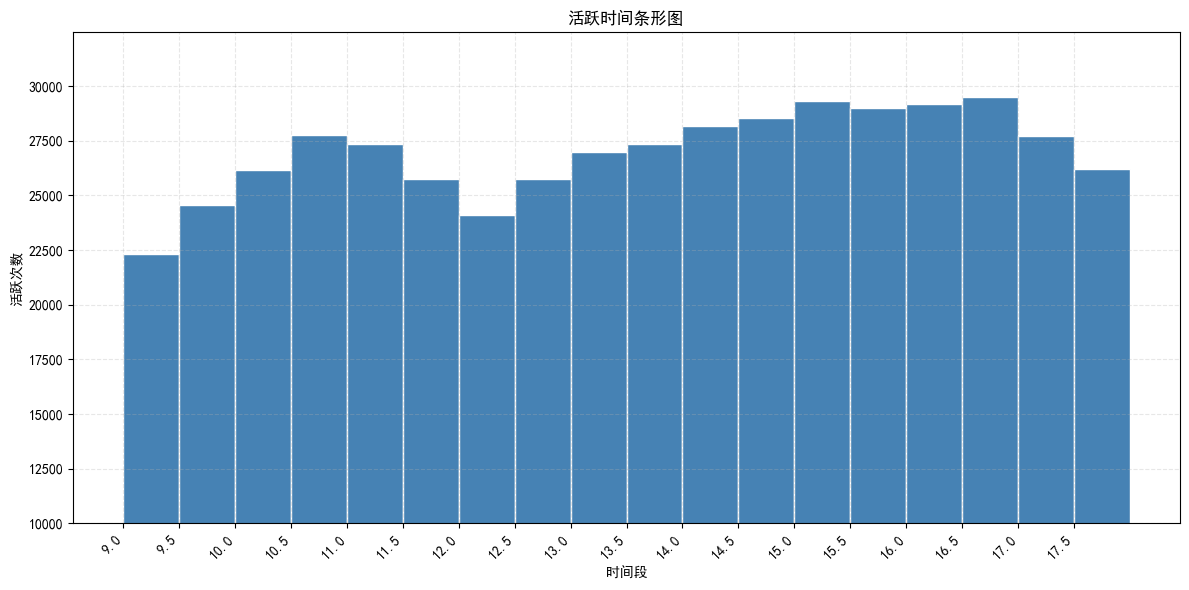

In [5]:

# 绘制折线图
plt.figure(figsize=(12, 6))
bars = plt.bar(
    frequency.index, 
    frequency.values, 
    width=1.0,        # 核心1：宽度设为1，实现无缝紧凑排列
    align='edge',     # 核心2：左对齐，让柱子起点与刻度线重合
    color='steelblue', 
    edgecolor='white' # 加上白色边框，方便区分相邻的柱子
)

# 4. 设置 X 轴标签（显示时间起点）
# 因为我们对齐到了边缘，这里可以加上旋转，防止标签重叠
plt.xticks(
    frequency.index, 
    [f"{h}" for h in frequency.index],  # 格式化为 HH:00
    rotation=45, 
    ha='right'
)

plt.ylim(10000, frequency.values.max() * 1.1) 
plt.title('活跃时间条形图')
plt.xlabel('时间段')
plt.ylabel('活跃次数')
# 5. 添加网格线，增强可读性
plt.grid(alpha=0.3, linestyle='--')
plt.tight_layout()
plt.show()


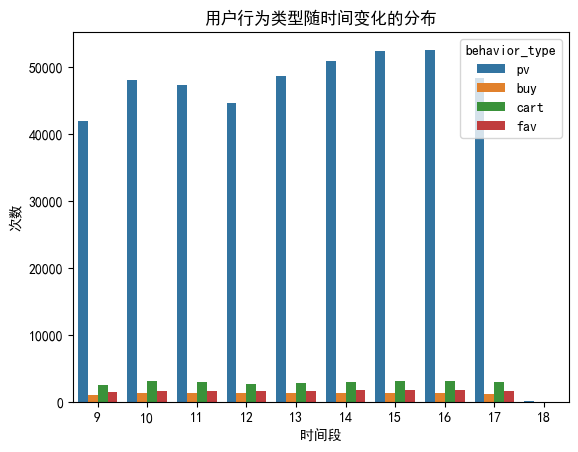

In [ ]:
usb['time_H']=usb['time'].dt.hour
sns.countplot(x='time_H',hue='behavior_type',data=usb)
plt.title('用户行为类型随时间变化的分布')  
plt.xlabel('时间段')
plt.ylabel('次数')
plt.show()

C:\Users\86151\AppData\Local\Temp\ipykernel_20288\1635478813.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


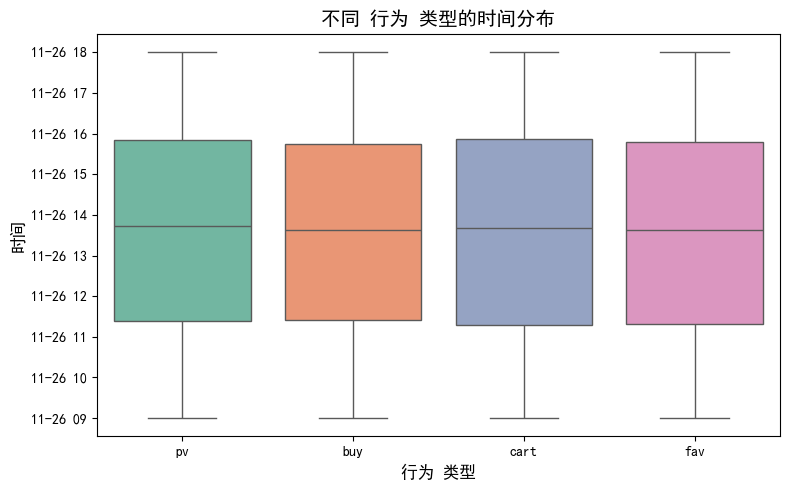

In [ ]:

# 绘制箱型图
plt.figure(figsize=(8, 5))  # 设置画布大小
sns.boxplot(
    x='behavior_type',              # X轴：分类变量
    y='time',    # Y轴：数值变量
    data=usb,                # 数据源
    palette='Set2'          # 设置配色方案
)

plt.title('不同 行为 类型的时间分布', fontsize=14)
plt.xlabel('行为 类型', fontsize=12)
plt.ylabel('时间', fontsize=12)

plt.tight_layout()
plt.show()

#白天用户行为习惯与时间相关性小

In [7]:
frequency_item_category = usb.pivot_table(index='item_category', columns='behavior_type', aggfunc='size', fill_value=0).sort_values(by='pv', ascending=False)
print("商品频数统计：\n",frequency_item_category)

商品频数统计：
 behavior_type  buy  cart  fav     pv
item_category                       
4756105        153  1047  682  21923
2355072         69   645  469  16284
4145813        181   815  532  15439
982926         127   778  459  13585
3607361         62   478  322  13167
...            ...   ...  ...    ...
2325377          0     0    1      0
2961965          0     1    0      0
2970693          0     1    0      0
2923285          2     0    0      0
5161669          1     2    0      0

[5614 rows x 4 columns]


用户行为频数统计：
     frequency   count  frequency_rate  cumulative_rate
0           1  122066        0.526346         0.526346
1           2   51242        0.220954         0.747301
2           3   25675        0.110710         0.858011
3           4   13596        0.058626         0.916636
4           5    7627        0.032887         0.949524
5           6    4400        0.018973         0.968497
6           7    2655        0.011448         0.979945
7           8    1549        0.006679         0.986624
8           9    1058        0.004562         0.991186
9          10     669        0.002885         0.994071
10         11     459        0.001979         0.996050
11         12     287        0.001238         0.997288
12         13     192        0.000828         0.998116
13         14     149        0.000642         0.998758
14         15      93        0.000401         0.999159
15         16      55        0.000237         0.999396
16         17      36        0.000155         0.999552

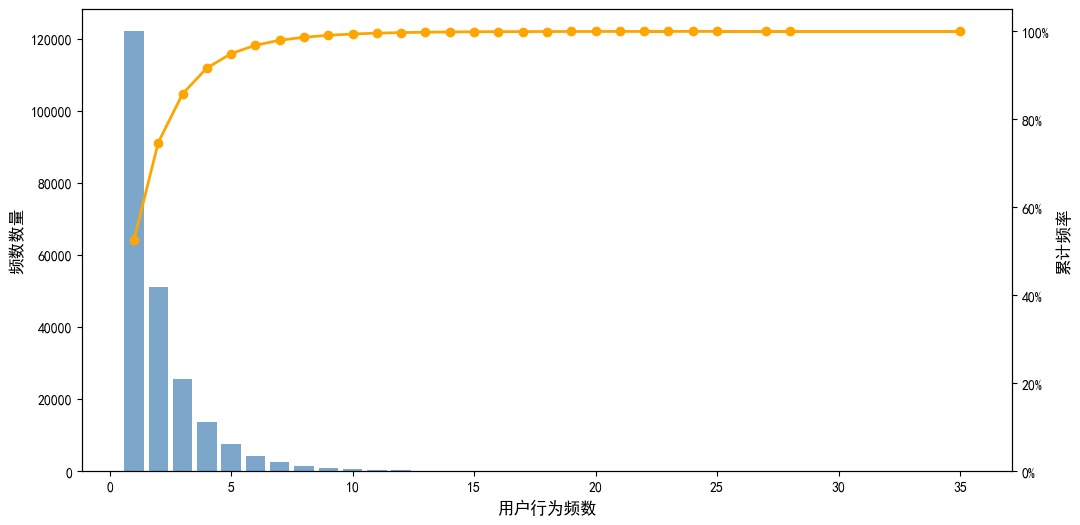

In [8]:
frequency_id=usb.groupby('use_id').size().reset_index(name='frequency').sort_values(by='frequency',ascending=False)
frequency_id_count=frequency_id['frequency'].value_counts().reset_index(name='count').sort_values(by='count',ascending=False)
frequency_id_count['frequency_rate']=frequency_id_count['count']/frequency_id_count['count'].sum()
frequency_id_count['cumulative_rate']=frequency_id_count['frequency_rate'].cumsum()
print("用户行为频数统计：\n",frequency_id_count)
## 统计用户行为帕累托图
fig, ax1 = plt.subplots(figsize=(12, 6))
# 绘制柱状图    
ax1.bar(frequency_id_count['frequency'], frequency_id_count['count'], color='steelblue', alpha=0.7)
ax1.set_xlabel('用户行为频数', fontsize=12)
ax1.set_ylabel('频数数量', fontsize=12)
# 绘制累计频率曲线
ax2 = ax1.twinx()
ax2.plot(frequency_id_count['frequency'], frequency_id_count['cumulative_rate'], color='orange', marker='o', linestyle='-', linewidth=2, markersize=6)
ax2.set_ylabel('累计频率', fontsize=12) 
ax2.set_ylim(0, 1.05)  # 设置累计频率的y轴范围为0到1.05，留出一点空间
ax2.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: '{:.0%}'.format(y)))  # 将y轴刻度格式化为百分比
plt.show()

In [ ]:
frequency_item_category=frequency_item_category[frequency_item_category['pv']>1000]
frequency_item_category['conversion_rate'] = frequency_item_category['buy'] / frequency_item_category['pv']
print("商品类别转化率统计：\n",frequency_item_category)

# 可详细对比点击率高的商品类别和点击率低的商品类别，分析其原因，进而优化商品类别的销售策略。

商品类别转化率统计：
 behavior_type  buy  cart  fav     pv  conversion_rate
item_category                                        
4756105        153  1047  682  21923         0.006979
2355072         69   645  469  16284         0.004237
4145813        181   815  532  15439         0.011724
982926         127   778  459  13585         0.009349
3607361         62   478  322  13167         0.004709
...            ...   ...  ...    ...              ...
3720767         19    82   36   1092         0.017399
3004853         24    65   48   1073         0.022367
4159072        104    66   31   1061         0.098021
4173315          6    46   27   1058         0.005671
4339722         24    72   20   1050         0.022857

[64 rows x 5 columns]


In [10]:
# 分析用户行为流向
from pandas import DataFrame


usebehavior=usb[['use_id','behavior_type','time']]
usebehavior['step'] = usebehavior.groupby('use_id').cumcount() 

usebehavior_st = usebehavior.groupby('use_id')['behavior_type'].agg(lambda x: '-->'.join(x)).reset_index()
print("用户行为流向统计：\n",usebehavior_st)


用户行为流向统计：
          use_id behavior_type
0             2       pv-->pv
1             6            pv
2             7            pv
3            11  pv-->pv-->pv
4            17  pv-->pv-->pv
...         ...           ...
231907  1017988       pv-->pv
231908  1017993     cart-->pv
231909  1018000       pv-->pv
231910  1018009            pv
231911  1018011            pv

[231912 rows x 2 columns]


In [11]:
usebehavior_sty=usebehavior_st.groupby('behavior_type').count()
usebehavior_sty=usebehavior_sty[usebehavior_sty['use_id']>1000].sort_values('use_id',ascending=False)
print(usebehavior_sty)

# 80%以上用户只点击产品没有收藏、购买，说明软件产品的推荐机制有问题，客户无法找到心仪的产品

                                  use_id
behavior_type                           
pv                                107124
pv-->pv                            40865
pv-->pv-->pv                       18988
pv-->pv-->pv-->pv                   9363
cart                                7366
pv-->pv-->pv-->pv-->pv              4876
buy                                 4052
fav                                 3524
pv-->pv-->pv-->pv-->pv-->pv         2676
pv-->cart                           2448
cart-->pv                           2378
pv-->pv-->pv-->pv-->pv-->pv-->pv    1536
pv-->buy                            1248
pv-->fav                            1170
fav-->pv                            1167
pv-->pv-->cart                      1026


In [12]:
#分析有购买产品的客户
grouped=usb.groupby('use_id')
new_usb=grouped.filter(lambda x: (x['behavior_type']=='buy').any())
print(new_usb)


# usebehavior_wide=usebehavior.pivot(index='use_id',columns='step',values='behavior_type')
# print(usebehavior_wide)

        use_id  item_id  item_category behavior_type                time  \
3       894923  3076029        1879194            pv 2017-11-26 09:00:00   
6       625915  1162383         570735            pv 2017-11-26 09:00:00   
16      813974  1332724        2520771           buy 2017-11-26 09:00:00   
23      946161  3021357        1506018            pv 2017-11-26 09:00:01   
33      487768  4125503        2465336            pv 2017-11-26 09:00:02   
...        ...      ...            ...           ...                 ...   
485593  495875  1014176         171529           buy 2017-11-26 17:59:51   
485656  146161  5082806        3002561           buy 2017-11-26 17:59:55   
485683  264944  4350516        2640118            pv 2017-11-26 17:59:57   
485685  380191  1564466        4078249           buy 2017-11-26 17:59:57   
485704  875701  4035733         174239           buy 2017-11-26 17:59:59   

       time_interval  time_H  
3                9.0       9  
6                9.0     

In [13]:
new_usebehavior=new_usb[['use_id','behavior_type','time']]
new_usebehavior['step']=new_usebehavior.groupby('use_id').cumcount()

usebehavior_wide_be=new_usebehavior.pivot(index='use_id',columns='step',values='behavior_type')
usebehavior_wide_ti=new_usebehavior.pivot(index='use_id',columns='step',values='time')
print(usebehavior_wide_be.head())
print(usebehavior_wide_ti.head())

step     0    1    2    3    4    5    6    7    8    9   ...   14   15   16  \
use_id                                                    ...                  
131     buy  buy   pv  NaN  NaN  NaN  NaN  NaN  NaN  NaN  ...  NaN  NaN  NaN   
216     fav  buy  NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN  ...  NaN  NaN  NaN   
531     buy  NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN  ...  NaN  NaN  NaN   
557      pv   pv  buy  NaN  NaN  NaN  NaN  NaN  NaN  NaN  ...  NaN  NaN  NaN   
748     buy  NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN  ...  NaN  NaN  NaN   

step     17   18   19   20   21   22   23  
use_id                                     
131     NaN  NaN  NaN  NaN  NaN  NaN  NaN  
216     NaN  NaN  NaN  NaN  NaN  NaN  NaN  
531     NaN  NaN  NaN  NaN  NaN  NaN  NaN  
557     NaN  NaN  NaN  NaN  NaN  NaN  NaN  
748     NaN  NaN  NaN  NaN  NaN  NaN  NaN  

[5 rows x 24 columns]
step                    0                   1                   2   3   4   \
use_id                        

In [14]:
#展示购买的客户流动轨迹
usebehavior_buy = new_usebehavior.groupby('use_id')['behavior_type'].agg(lambda x: '-->'.join(x)).reset_index()
usebehavior_buy=usebehavior_buy.groupby('behavior_type').count()
usebehavior_buy=usebehavior_buy[usebehavior_buy['use_id']>30].sort_values('use_id',ascending=False)
print(usebehavior_buy)

#表示超80%的购买的用户是有目标购买，且往往会选择点击的前几个商品购买，再次说明商品listing的重要性


                                   use_id
behavior_type                            
buy                                  4052
pv-->buy                             1248
buy-->pv                              832
pv-->pv-->buy                         533
buy-->pv-->pv                         306
pv-->buy-->pv                         285
pv-->pv-->pv-->buy                    229
pv-->pv-->buy-->pv                    169
pv-->pv-->pv-->pv-->buy               149
buy-->pv-->pv-->pv                    148
pv-->buy-->pv-->pv                    129
buy-->buy                             122
buy-->pv-->pv-->pv-->pv                80
cart-->buy                             78
pv-->pv-->pv-->buy-->pv                78
pv-->pv-->buy-->pv-->pv                72
buy-->cart                             68
pv-->pv-->pv-->pv-->pv-->buy           66
pv-->buy-->pv-->pv-->pv                61
pv-->pv-->pv-->pv-->pv-->pv-->buy      49
fav-->buy                              46
pv-->buy-->pv-->pv-->pv-->pv      

time_interval
9.0     463
9.5     529
10.0    618
10.5    640
11.0    670
11.5    643
12.0    599
12.5    643
13.0    601
13.5    691
14.0    650
14.5    650
15.0    606
15.5    710
16.0    660
16.5    621
17.0    610
17.5    557
dtype: int64
